In [18]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, join

In [25]:
def rotation_period(cluster_name):
    rot_file = f"RotationPeriodRV_{cluster_name}.csv"
    fits_file = f"rcat_ngc{cluster_name}_v0.fits"
    
    rot = Table.read(rot_file, format="csv")
    rcat = Table.read(fits_file)
    
    rot["GAIAEDR3_ID"] = rot["Gaia"]
    
    merged = join(rot, rcat, keys="GAIAEDR3_ID", join_type="inner")
    
    mask = merged["MemBool"] == 1
    merged = merged[mask]
    
    bp_rp = merged["BP-RP"]
    per = merged["Per"]
    G = merged["GAIAEDR3_G_CORRECTED"]
    dist = merged["dist"]
    
    cleandata = (
        np.isfinite(bp_rp) &
        np.isfinite(per) &
        np.isfinite(G) &
        np.isfinite(dist) &
        (dist > 0)
    )
    
    bp_rp = bp_rp[cleandata]
    per = per[cleandata]
    G = G[cleandata]
    dist = dist[cleandata]
    
    MG = G - 5 * np.log10(dist) + 5
    
    order = np.argsort(per)
    bp_rp = bp_rp[order]
    MG = MG[order]
    per = per[order]
    
    plt.scatter(bp_rp, MG, c=per, s=10)
    plt.gca().invert_yaxis()
    
    cbar = plt.colorbar()
    cbar.set_label("Rotation Period (days)")
    
    plt.xlabel("BP - RP")
    plt.ylabel("M_G")
    plt.show()

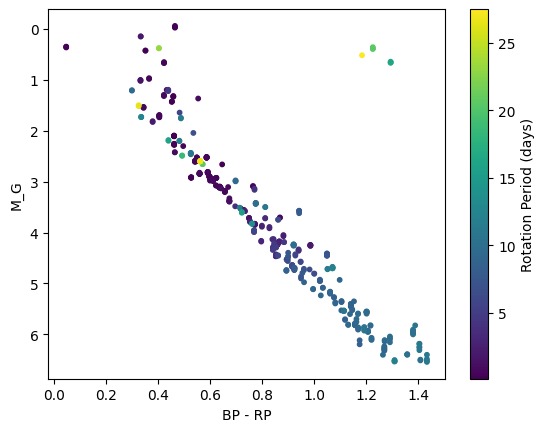

In [27]:
rotation_period('6866')